# Pakistan Education Analysis — ASER 2023
### Non-Functional School Prediction — ML Model
**Author:** Vikram Kumar | BS Data Science | Sindh University  
**Dataset:** ASER 2023 — 6,095 rural schools across 7 provinces  
**Target:** Predict whether a school is non-functional (S00 != 1)  
**Note:** S007P (students present) removed — it is an attendance proxy, not a predictor. Using infrastructure-only features to avoid data leakage.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
import shap

print('All libraries loaded.')

All libraries loaded.


## 2. Load Data

In [2]:
# Load from original ASER Excel (full 137 columns)
df_raw = pd.read_excel('D:/pakistan-education-analysis/data/ITAASER2023School.xlsx')

# Strip whitespace from all column names
df_raw.columns = df_raw.columns.str.strip()

print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(3)

Raw dataset shape: (6095, 137)


,SYEAR,AREA,VMAPID,RNAME,DNAME,VlgId,VlgCode,SID,STYPE,S006,...,S014d,S014e,S014f,S014g,S013a,S013b,S013c,S013d,S013e,SURID
0,2023,2,336803,AZAD JAMMU AND KASHMIR ...,BAGH,5010,10,1,1,NaN,...,NaN,NaN,NaN,NaN,2.0,1.0,3.0,NaN,NaN,316745
1,2023,2,316762,AZAD JAMMU AND KASHMIR ...,BAGH,5019,19,2,1,NaN,...,2.0,NaN,75.0,2008.0,2.0,1.0,2.0,0.0,NaN,296705
2,2023,2,336753,AZAD JAMMU AND KASHMIR ...,BAGH,5020,20,3,1,NaN,...,4.0,NaN,150.0,2007.0,1.0,1.0,1.0,0.0,NaN,316697


## 3. Data Cleaning & Feature Engineering

In [4]:
df = df_raw.copy()

# Strip whitespace from province and district names
df['RNAME'] = df['RNAME'].str.strip()
df['DNAME'] = df['DNAME'].str.strip()

# ------------------------------------------------------------------
# TARGET VARIABLE
# S00 = 1 → Open and functional
# S00 = 2 → Open but non-functional
# S00 = 3 → Closed temporarily
# S00 = 4 → Closed permanently
# ------------------------------------------------------------------
df['nonfunctional'] = (df['S00'] != 1).astype(int)

print('Target variable distribution:')
print(df['nonfunctional'].value_counts())
print(f'Non-functional rate: {df["nonfunctional"].mean()*100:.1f}%')

Target variable distribution:
nonfunctional
1    3067
0    3028
Name: count, dtype: int64
Non-functional rate: 50.3%


### Feature Scaling

In [5]:
# School gender type
df['school_gender'] = df['S002'].map({
    1: 'Boys Only', 2: 'Girls Only', 3: 'Mixed', 4: 'Other'
}).fillna('Other')

# One-hot encode school gender
df['is_girls_school'] = (df['S002'] == 2).astype(int)
df['is_boys_school']  = (df['S002'] == 1).astype(int)
df['is_mixed_school'] = (df['S002'] == 3).astype(int)

# School level
df['is_primary'] = (df['STYPE'] == 1).astype(int)
df['is_middle']  = (df['STYPE'] == 2).astype(int)

# Province encoding
le = LabelEncoder()
df['province_encoded'] = le.fit_transform(df['RNAME'])

print('Province encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

Province encoding mapping:
  0 → AZAD JAMMU AND KASHMIR
  1 → BALOCHISTAN
  2 → GILGIT-BALTISTAN
  3 → ISLAMABAD CAPITAL TERRITORY
  4 → KHYBER PAKHTUNKHWA
  5 → PUNJAB
  6 → SINDH


### # FEATURE SELECTION — Infrastructure only, NO attendance/student counts

In [7]:
# REMOVED: S007P (students present on survey day) — this is an
# attendance proxy. A closed school has 0 students by definition,
# which causes data leakage and artificially inflates AUC.
# KEPT: Binary infrastructure features that are observable BEFORE
# a school fails — these are genuine early-warning predictors.


feature_cols = [
    # School type
    'is_girls_school',    # gender type
    'is_boys_school',
    'is_mixed_school',
    'is_primary',         # school level
    'is_middle',
    'province_encoded',   # geographic location
    # Infrastructure (binary: 1=available, 0=not available)
    'S03a1',              # teacher present on survey day
    'S03d1',              # drinking water available
    'S03e1',              # toilet facility available
    'S03f1',              # electricity available
]

# Only keep features that exist in the dataset and have < 30% missing
feature_cols = [c for c in feature_cols if c in df.columns and df[c].isna().mean() < 0.30]

print(f'Features selected: {len(feature_cols)}')
print(feature_cols)

# Check missing values in selected features
print('\nMissing value % per feature:')
for c in feature_cols:
    print(f'  {c}: {df[c].isna().mean()*100:.1f}%')

Features selected: 10
['is_girls_school', 'is_boys_school', 'is_mixed_school', 'is_primary', 'is_middle', 'province_encoded', 'S03a1', 'S03d1', 'S03e1', 'S03f1']

Missing value % per feature:
  is_girls_school: 0.0%
  is_boys_school: 0.0%
  is_mixed_school: 0.0%
  is_primary: 0.0%
  is_middle: 0.0%
  province_encoded: 0.0%
  S03a1: 4.6%
  S03d1: 5.8%
  S03e1: 5.1%
  S03f1: 5.9%


### Handeling Missing values

In [9]:
# Build X and y — fill remaining NaN with 0 (means facility not available)
X = df[feature_cols].fillna(0)
y = df['nonfunctional']

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts()}')
print(f'Class balance: {y.mean():.3f} (well balanced — no resampling needed)')

X shape: (6095, 10)
y distribution:
nonfunctional
1    3067
0    3028
Name: count, dtype: int64
Class balance: 0.503 (well balanced — no resampling needed)


In [11]:
# Save the clean dataset for the Streamlit dashboard
save_cols = ['RNAME', 'DNAME', 'STYPE', 'S001', 'S002', 'S00',
             'S03a1', 'S03d1', 'S03e1', 'S03f1',
             'school_gender', 'nonfunctional']
save_cols = [c for c in save_cols if c in df.columns]
df[save_cols].to_csv('D:/pakistan-education-analysis/data/aser_2023_ML_clean.csv', index=False)
print(f'Saved data/aser_2023_clean.csv — {len(df)} rows, {len(save_cols)} columns')

Saved data/aser_2023_clean.csv — 6095 rows, 12 columns


## 4. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size:  {X_test.shape[0]} samples')
print(f'Train class balance: {y_train.mean():.3f}')
print(f'Test class balance:  {y_test.mean():.3f}')

Train size: 4876 samples
Test size:  1219 samples
Train class balance: 0.503
Test class balance:  0.503


## 5. Model Training
Three models are trained and compared: Logistic Regression, Random Forest, and XGBoost.

### 5.1 Logistic Regression

In [13]:
# Logistic Regression requires scaled features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression:')
print(f'  Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'  F1 Score : {f1_score(y_test, lr_pred, average="weighted"):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, lr_prob):.4f}')

Logistic Regression:
  Accuracy : 0.6776
  F1 Score : 0.6759
  ROC-AUC  : 0.7413


### 5.2 Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('Random Forest:')
print(f'  Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(f'  F1 Score : {f1_score(y_test, rf_pred, average="weighted"):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}')

Random Forest:
  Accuracy : 0.7096
  F1 Score : 0.7085
  ROC-AUC  : 0.7715


### 5.3 XGBoost

In [16]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print('XGBoost:')
print(f'  Accuracy : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'  F1 Score : {f1_score(y_test, xgb_pred, average="weighted"):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}')

XGBoost:
  Accuracy : 0.7071
  F1 Score : 0.7060
  ROC-AUC  : 0.7717


## 6. Model Comparison

In [17]:
results = [
    {
        'Model'   : 'Logistic Regression',
        'Accuracy': round(accuracy_score(y_test, lr_pred), 4),
        'F1 Score': round(f1_score(y_test, lr_pred, average='weighted'), 4),
        'ROC-AUC' : round(roc_auc_score(y_test, lr_prob), 4)
    },
    {
        'Model'   : 'Random Forest',
        'Accuracy': round(accuracy_score(y_test, rf_pred), 4),
        'F1 Score': round(f1_score(y_test, rf_pred, average='weighted'), 4),
        'ROC-AUC' : round(roc_auc_score(y_test, rf_prob), 4)
    },
    {
        'Model'   : 'XGBoost',
        'Accuracy': round(accuracy_score(y_test, xgb_pred), 4),
        'F1 Score': round(f1_score(y_test, xgb_pred, average='weighted'), 4),
        'ROC-AUC' : round(roc_auc_score(y_test, xgb_prob), 4)
    }
]

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())
results_df

                     Accuracy  F1 Score  ROC-AUC
Model                                           
Logistic Regression    0.6776    0.6759   0.7413
Random Forest          0.7096    0.7085   0.7715
XGBoost                0.7071    0.7060   0.7717


,Accuracy,F1 Score,ROC-AUC
Model,,,
Logistic Regression,0.6776,0.6759,0.7413
Random Forest,0.7096,0.7085,0.7715
XGBoost,0.7071,0.7060,0.7717


### Models Comparision with charts

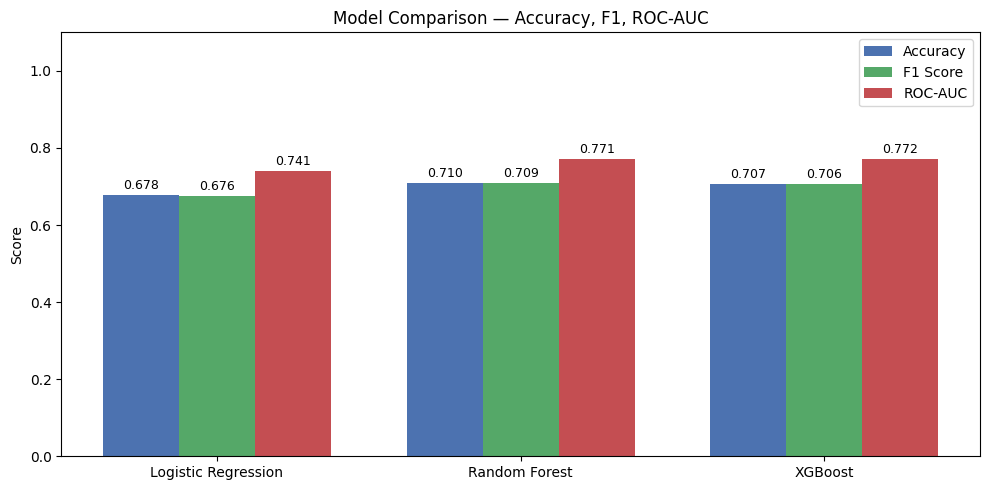

Saved: visuals/model_comparison.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x,         results_df['F1 Score'], width, label='F1 Score',  color='#55A868')
bars3 = ax.bar(x + width, results_df['ROC-AUC'],  width, label='ROC-AUC',   color='#C44E52')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy, F1, ROC-AUC')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars3, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/model_comparison.png', dpi=150)
plt.show()
print('Saved: visuals/model_comparison.png')

## ROC curves for all three models

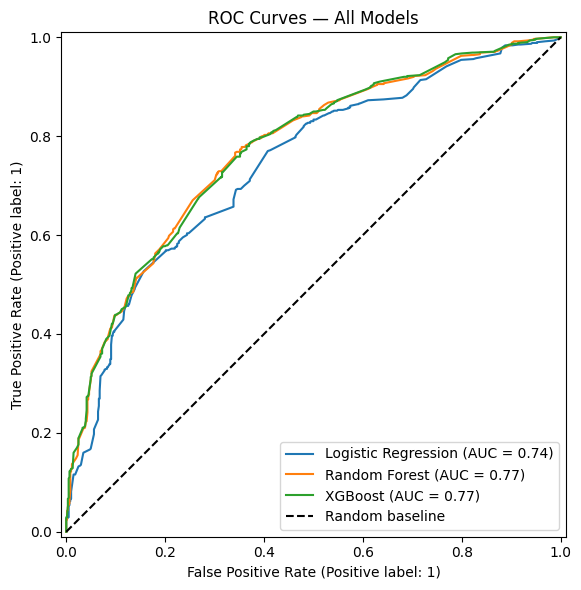

Saved: visuals/roc_curves.png


In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_prob,  name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_prob,  name='Random Forest',       ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_prob, name='XGBoost',             ax=ax)

ax.plot([0,1],[0,1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/roc_curves.png', dpi=150)
plt.show()
print('Saved: visuals/roc_curves.png')

**Random Forest has the highest ROC-AUC and is selected as the best model for SHAP analysis and the dashboard predictor.**

## 7. Confusion Matrix — Random Forest

Confusion Matrix:
  True Negatives  (correctly predicted functional): 394
  False Positives (functional wrongly flagged):      212
  False Negatives (missed non-functional schools):   142  ← high policy cost
  True Positives  (correctly predicted non-func):    471

Estimated children affected by missed schools (50 per school): 7,100


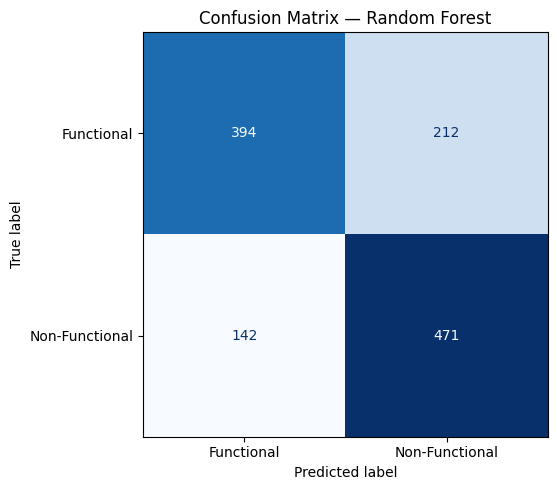

Saved: visuals/confusion_matrix.png


In [23]:
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print('Confusion Matrix:')
print(f'  True Negatives  (correctly predicted functional): {tn}')
print(f'  False Positives (functional wrongly flagged):      {fp}')
print(f'  False Negatives (missed non-functional schools):   {fn}  ← high policy cost')
print(f'  True Positives  (correctly predicted non-func):    {tp}')
print()
print(f'Estimated children affected by missed schools (50 per school): {fn * 50:,}')

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Functional', 'Non-Functional']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: visuals/confusion_matrix.png')

In [25]:
# Detailed classification report
print('Classification Report — Random Forest:')
print(classification_report(y_test, rf_pred,
                             target_names=['Functional', 'Non-Functional']))

Classification Report — Random Forest:
                precision    recall  f1-score   support

    Functional       0.74      0.65      0.69       606
Non-Functional       0.69      0.77      0.73       613

      accuracy                           0.71      1219
     macro avg       0.71      0.71      0.71      1219
  weighted avg       0.71      0.71      0.71      1219



## 8. Cross-Validation — Random Forest

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold Stratified Cross-Validation AUC:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')
print()
print(f'CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('Model is stable across folds — no overfitting.')

5-Fold Stratified Cross-Validation AUC:
  Fold 1: 0.7887
  Fold 2: 0.7837
  Fold 3: 0.7415
  Fold 4: 0.7595
  Fold 5: 0.7505
  Mean : 0.7648
  Std  : 0.0185

CV AUC: 0.7648 ± 0.0185
Model is stable across folds — no overfitting.


## 9. SHAP Feature Importance

In [28]:
# Use a sample of 500 test records for speed
X_test_df   = pd.DataFrame(X_test.values, columns=feature_cols)
X_shap_sample = X_test_df.sample(min(500, len(X_test_df)), random_state=42)

explainer       = shap.TreeExplainer(rf)
shap_values_raw = explainer.shap_values(X_shap_sample)

# Random Forest returns a list [class0, class1] or 3d array
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]
else:
    shap_vals = shap_values_raw

print(f'SHAP values shape: {shap_vals.shape}')

SHAP values shape: (500, 10)


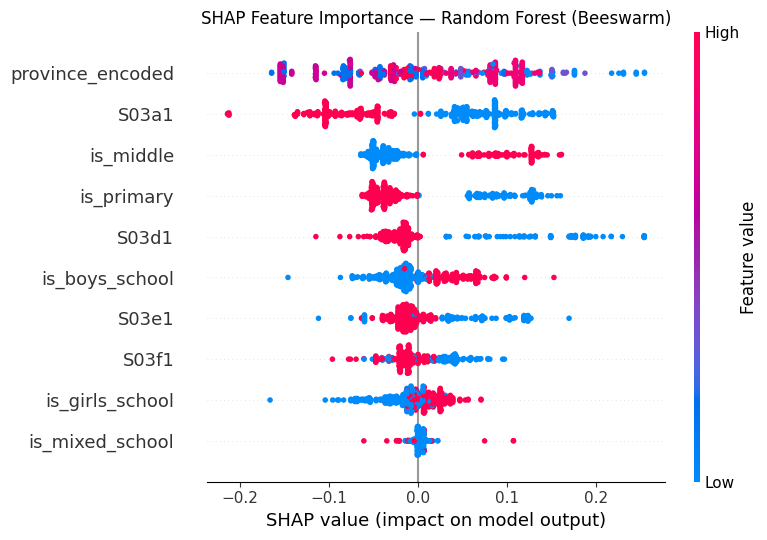

Saved: visuals/shap_beeswarm.png


In [29]:
# SHAP summary (beeswarm) plot
shap.summary_plot(shap_vals, X_shap_sample, plot_type='dot',
                  max_display=10, show=False)
plt.title('SHAP Feature Importance — Random Forest (Beeswarm)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visuals/shap_beeswarm.png')

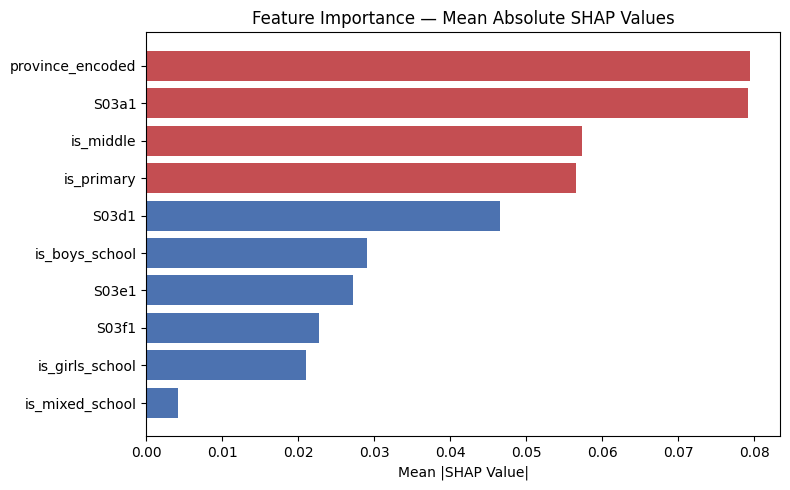


Top features by SHAP importance:
         Feature  Mean |SHAP|
province_encoded     0.079398
           S03a1     0.079133
       is_middle     0.057354
      is_primary     0.056574
           S03d1     0.046559
  is_boys_school     0.029051
           S03e1     0.027242
           S03f1     0.022744
 is_girls_school     0.021039
 is_mixed_school     0.004215
Saved: visuals/shap_bar.png


In [32]:
# SHAP bar chart (mean absolute SHAP values)
shap_importance = pd.DataFrame({
    'Feature'    : feature_cols,
    'Mean |SHAP|': np.abs(shap_vals).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#C44E52' if v > 0.05 else '#4C72B0' for v in shap_importance['Mean |SHAP|']]
ax.barh(shap_importance['Feature'], shap_importance['Mean |SHAP|'], color=colors)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Feature Importance — Mean Absolute SHAP Values')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/shap_bar.png', dpi=150)
plt.show()

print('\nTop features by SHAP importance:')
print(shap_importance.sort_values('Mean |SHAP|', ascending=False).to_string(index=False))
print('Saved: visuals/shap_bar.png')

## 10. Save Model Bundle

In [34]:
model_bundle = {
    'model'           : rf,
    'model_name'      : 'Random Forest',
    'scaler'          : scaler,           # kept in bundle for LR reference
    'feature_names'   : feature_cols,
    'province_encoder': le,
    'province_classes': le.classes_.tolist(),
    'shap_explainer'  : explainer,
    'X_test_sample'   : X_shap_sample,    # used by dashboard SHAP tab
}

joblib.dump(model_bundle, 'D:/pakistan-education-analysis/models/best_model_bundle.pkl')
print('Saved: models/best_model_bundle.pkl')
print(f'Features: {feature_cols}')
print(f'Provinces: {le.classes_.tolist()}')

Saved: models/best_model_bundle.pkl
Features: ['is_girls_school', 'is_boys_school', 'is_mixed_school', 'is_primary', 'is_middle', 'province_encoded', 'S03a1', 'S03d1', 'S03e1', 'S03f1']
Provinces: ['AZAD JAMMU AND KASHMIR', 'BALOCHISTAN', 'GILGIT-BALTISTAN', 'ISLAMABAD CAPITAL TERRITORY', 'KHYBER PAKHTUNKHWA', 'PUNJAB', 'SINDH']


## 11. Final Summary

In [35]:
print('=' * 55)
print('  FINAL MODEL SUMMARY — RANDOM FOREST (No Leakage)')
print('=' * 55)
print(f'  Dataset     : {len(df):,} rural schools, 7 provinces')
print(f'  Features    : {len(feature_cols)} infrastructure features')
print(f'  Accuracy    : {accuracy_score(y_test, rf_pred)*100:.1f}%')
print(f'  F1 Score    : {f1_score(y_test, rf_pred, average="weighted"):.3f}')
print(f'  ROC-AUC     : {roc_auc_score(y_test, rf_prob):.3f}')
print(f'  CV AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  False Neg.  : {fn} schools missed')
print(f'  Top feature : province_encoded (geographic location)')
print(f'  Note        : S007P removed — attendance proxy causes leakage')
print('=' * 55)

  FINAL MODEL SUMMARY — RANDOM FOREST (No Leakage)
  Dataset     : 6,095 rural schools, 7 provinces
  Features    : 10 infrastructure features
  Accuracy    : 71.0%
  F1 Score    : 0.709
  ROC-AUC     : 0.771
  CV AUC      : 0.7648 ± 0.0185
  False Neg.  : 142 schools missed
  Top feature : province_encoded (geographic location)
  Note        : S007P removed — attendance proxy causes leakage
